# Análise exploratória e XGBoost
Este notebook carrega os dados, cria um proxy de risco por sessão e treina um modelo XGBoost simples.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import xgboost as xgb

warnings.filterwarnings("ignore")

# Diretório base do notebook.
BASE_DIR = Path(r"c:\Users\josuc\OneDrive - PUCRS - BR\PUCRS\2026_01\TCC\AnaliseExploratória")

# O OhioDataset já traz a separação original em treino e teste.
# Usamos essa estrutura para evitar que amostras de teste apareçam no treinamento.
TRAIN_DIRS = [
    BASE_DIR / "Ohio2018_processed" / "train",
    BASE_DIR / "Ohio2020_processed" / "train",
]
TEST_DIRS = [
    BASE_DIR / "Ohio2018_processed" / "test",
    BASE_DIR / "Ohio2020_processed" / "test",
]

print("BASE_DIR exists:", BASE_DIR.exists())
print("Train directories:")
for directory in TRAIN_DIRS:
    print(" -", directory, "exists=", directory.exists())
print("Test directories:")
for directory in TEST_DIRS:
    print(" -", directory, "exists=", directory.exists())

# Este contador serve apenas para conferência rápida da estrutura do conjunto de dados.
all_csv_files = []
for directory in TRAIN_DIRS + TEST_DIRS:
    all_csv_files.extend(directory.rglob("*_processed.csv"))
print("CSV files found in predefined splits:", len(all_csv_files))


BASE_DIR exists: True
Train directories:
 - c:\Users\josuc\OneDrive - PUCRS - BR\PUCRS\2026_01\TCC\AnaliseExploratória\Ohio2018_processed\train exists= True
 - c:\Users\josuc\OneDrive - PUCRS - BR\PUCRS\2026_01\TCC\AnaliseExploratória\Ohio2020_processed\train exists= True
Test directories:
 - c:\Users\josuc\OneDrive - PUCRS - BR\PUCRS\2026_01\TCC\AnaliseExploratória\Ohio2018_processed\test exists= True
 - c:\Users\josuc\OneDrive - PUCRS - BR\PUCRS\2026_01\TCC\AnaliseExploratória\Ohio2020_processed\test exists= True
CSV files found in predefined splits: 24


In [11]:
def load_split_csvs(split_dirs):
    """Carrega todos os CSVs processados de uma lista de pastas de partição."""
    datasets = {}
    for split_dir in split_dirs:
        if not split_dir.exists():
            print(f"Split directory not found: {split_dir}")
            continue

        # Cada arquivo é lido com base na partição original para preservar a separação do OhioDataset.
        for file_path in sorted(split_dir.rglob("*_processed.csv")):
            dataset_key = file_path.relative_to(BASE_DIR).with_suffix("").as_posix().replace("/", "__")
            try:
                datasets[dataset_key] = pd.read_csv(file_path)
            except Exception as error:
                print(f"Failed to read {file_path}: {error}")

    return datasets


def preprocess_df(df):
    """Padroniza os tipos das colunas numéricas usadas na análise."""
    df = df.copy()
    numeric_cols = ["missing_cbg", "cbg", "finger", "basal", "hr", "gsr", "carbInput", "bolus"]

    # Convertemos tudo para numérico para facilitar a agregação por janela temporal.
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # missing_cbg é um indicador binário; preencher NaN com 0 evita que valores ausentes virem ruído no agregado.
    if "missing_cbg" in df.columns:
        df["missing_cbg"] = df["missing_cbg"].fillna(0)

    return df


def derive_risk_score(df):
    """
    Calcula um score ordinal de risco (0 a 5) com base em sinais clínicos simples.
    O objetivo aqui é gerar um alvo interpretável para o modelo, não substituir avaliação médica.
    """
    cbg_max = float(df["cbg"].max(skipna=True)) if "cbg" in df.columns and not df["cbg"].dropna().empty else np.nan
    cbg_high_frac = float((df["cbg"] >= 250).sum() / len(df)) if "cbg" in df.columns and len(df) > 0 else 0.0
    missing_ratio = float(df["missing_cbg"].mean()) if "missing_cbg" in df.columns else 0.0

    # Cada regra adiciona evidência de risco e o score final é limitado ao intervalo esperado.
    risk_score = (
        int(cbg_high_frac >= 0.05)
        + int(cbg_high_frac >= 0.15)
        + int(cbg_max >= 300)
        + int(missing_ratio >= 0.10)
        + int(missing_ratio >= 0.25)
    )
    return int(risk_score)


def feature_engineer(df):
    """Resume cada sessão em estatísticas agregadas para uso no modelo."""
    df = df.copy()
    feats = {}

    # Calculamos estatísticas simples por variável para capturar tendência, dispersão e extremos.
    for col in ["cbg", "hr", "gsr", "carbInput", "bolus", "basal"]:
        if col in df.columns:
            series = df[col].dropna()
            feats[f"{col}_mean"] = float(df[col].mean(skipna=True)) if not series.empty else np.nan
            feats[f"{col}_std"] = float(df[col].std(skipna=True)) if not series.empty else np.nan
            feats[f"{col}_max"] = float(df[col].max(skipna=True)) if not series.empty else np.nan
            feats[f"{col}_min"] = float(df[col].min(skipna=True)) if not series.empty else np.nan

    if "missing_cbg" in df.columns:
        feats["missing_cbg_frac"] = float(df["missing_cbg"].fillna(0).mean())

    feats["n_rows"] = int(len(df))
    return feats


def prepare_dataset(split_dirs):
    """Cria um dataset tabular agregado a partir de uma lista de partições."""
    datasets = load_split_csvs(split_dirs)
    rows = []

    for session_key, df in datasets.items():
        dfp = preprocess_df(df)
        feats = feature_engineer(dfp)
        feats["session"] = session_key
        feats["risk_score"] = derive_risk_score(dfp)
        rows.append(feats)

    return pd.DataFrame(rows)


def train_xgb(train_df, test_df, label_col="risk_score", random_state=42):
    """Treina o XGBoost apenas no treino e mede o desempenho no teste."""
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df = train_df.dropna(axis=1, how="all")
    test_df = test_df.dropna(axis=1, how="all")
    if label_col not in train_df.columns or label_col not in test_df.columns:
        raise ValueError("label column missing")

    # Separação explícita entre treino e teste: o modelo só enxerga os dados de treino no ajuste.
    X_train = train_df.drop([label_col, "session"], axis=1, errors="ignore")
    y_train = train_df[label_col]
    X_test = test_df.drop([label_col, "session"], axis=1, errors="ignore")
    y_test = test_df[label_col]

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=random_state)
    model.fit(X_train.fillna(0), y_train)
    y_pred = model.predict(X_test.fillna(0))
    y_proba = model.predict_proba(X_test.fillna(0))[:, 1] if hasattr(model, "predict_proba") else None

    return model, X_train, X_test, y_train, y_test, {
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None and len(np.unique(y_test)) > 1 else None,
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
    }


def train_xgb_ordinal(train_df, test_df, label_col="risk_score", random_state=42):
    """Treina o XGBoost para alvo ordinal usando treino e teste já definidos pelo dataset."""
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df = train_df.dropna(axis=1, how="all")
    test_df = test_df.dropna(axis=1, how="all")
    if label_col not in train_df.columns or label_col not in test_df.columns:
        raise ValueError(f"{label_col} column missing")

    # O conjunto de teste fica reservado para avaliação final, sem participar do treino.
    X_train = train_df.drop([label_col, "session", "window_id"], axis=1, errors="ignore")
    y_train = train_df[label_col]
    X_test = test_df.drop([label_col, "session", "window_id"], axis=1, errors="ignore")
    y_test = test_df[label_col]

    # Alinhamos as colunas para garantir que as mesmas variáveis usadas no treino existam no teste.
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    from sklearn.metrics import mean_squared_error, mean_absolute_error

    model = xgb.XGBRegressor(random_state=random_state, n_estimators=100)
    model.fit(X_train.fillna(0), y_train)
    y_pred = np.round(model.predict(X_test.fillna(0))).astype(int)
    y_pred = np.clip(y_pred, 0, 5)

    return model, X_train, X_test, y_train, y_test, {
        "mse": mean_squared_error(y_test, y_pred),
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
    }


def evaluate_model(metrics):
    """Imprime as métricas calculadas para facilitar a leitura do notebook."""
    print("Evaluation metrics:")
    for key, value in metrics.items():
        print(f"{key}: {value}")


## Temporal Windows for Risk Prediction
Train on features from week t to predict risk in week t+1.
The train/test separation follows the original OhioDataset split, so the test partition is never used during fitting.
Use 7-day or 14-day windows depending on DKA development timeframe.


In [4]:
# Exemplo: criar janelas de 7 dias respeitando a divisão original do OhioDataset.
# O conjunto de treino é usado para ajustar o modelo e o conjunto de teste fica reservado para a avaliação final.
temporal_dataset = create_temporal_windows(TRAIN_DIRS, window_days=7)
temporal_dataset_test = create_temporal_windows(TEST_DIRS, window_days=7)

print("Temporal dataset (train) shape:", temporal_dataset.shape)
print("Temporal dataset (test) shape:", temporal_dataset_test.shape)
print("\nRisk score distribution - train:")
print(temporal_dataset["risk_score"].value_counts().sort_index())
print("\nRisk score distribution - test:")
print(temporal_dataset_test["risk_score"].value_counts().sort_index())
print("\nFirst few train rows:")
print(temporal_dataset.head(10))

# Treinamos com a partição de treino e avaliamos diretamente na partição de teste.
if len(temporal_dataset) >= 4 and len(temporal_dataset_test) >= 1 and temporal_dataset["risk_score"].std() > 0:
    print("\n--- Training on temporal windows with risk_score target ---")
    model_temporal, X_train_t, X_test_t, y_train_t, y_test_t, metrics_t = train_xgb_ordinal(
        temporal_dataset,
        temporal_dataset_test,
        label_col="risk_score"
    )
    print("Temporal model metrics (ordinal regression):")
    evaluate_model(metrics_t)
    print(f"\nActual test scores: min={y_test_t.min()}, max={y_test_t.max()}, mean={y_test_t.mean():.2f}")
else:
    print("Not enough variability in temporal training dataset for training.")


Temporal dataset (train) shape: (69, 29)
Temporal dataset (test) shape: (12, 29)

Risk score distribution - train:
risk_score
0     9
1    11
2    25
3    17
4     6
5     1
Name: count, dtype: int64

Risk score distribution - test:
risk_score
0    2
1    2
2    5
3    2
4    1
Name: count, dtype: int64

First few train rows:
     cbg_mean    cbg_std  cbg_max  cbg_min    hr_mean     hr_std  hr_max  \
0  171.071390  75.340932    400.0     51.0  74.205717  12.799272   151.0   
1  170.257713  67.074180    366.0     59.0  73.208400  14.478640   134.0   
2  179.715337  76.307159    400.0     45.0  74.264631  14.584824   189.0   
3  153.624416  59.762826    317.0     40.0  73.708248  16.983343   147.0   
4  158.214366  69.837206    400.0     51.0  74.699535  17.591395   148.0   
5  134.330633  38.222971    282.0     49.0  93.488082  14.590086   155.0   
6  134.177041  47.173350    332.0     51.0  98.354872  14.672313   167.0   
7  143.254157  39.719779    261.0     52.0  98.019477  14.254595

## Comparação: 7 dias vs 14 dias
Treinar modelos em ambas as janelas, sempre com treino e teste separados de acordo com a divisão original do OhioDataset, e visualizar os resultados.


In [6]:
# Repetimos a análise com janelas de 14 dias para comparar a sensibilidade temporal.
temporal_dataset_14 = create_temporal_windows(TRAIN_DIRS, window_days=14)
temporal_dataset_14_test = create_temporal_windows(TEST_DIRS, window_days=14)

print("=" * 60)
print("14-DAY WINDOWS")
print("=" * 60)
print(f"Dataset shape (train): {temporal_dataset_14.shape}")
print(f"Dataset shape (test): {temporal_dataset_14_test.shape}")
print("\nRisk score distribution - train:")
print(temporal_dataset_14["risk_score"].value_counts().sort_index())
print("\nRisk score distribution - test:")
if len(temporal_dataset_14_test) > 0 and "risk_score" in temporal_dataset_14_test.columns:
    print(temporal_dataset_14_test["risk_score"].value_counts().sort_index())
else:
    print("No 14-day windows were generated in the test split.")

# O treino continua restrito à partição de treino original.
if len(temporal_dataset_14) >= 4 and len(temporal_dataset_14_test) >= 1 and temporal_dataset_14["risk_score"].std() > 0:
    model_temporal_14, X_train_t14, X_test_t14, y_train_t14, y_test_t14, metrics_t14 = train_xgb_ordinal(
        temporal_dataset_14,
        temporal_dataset_14_test,
        label_col="risk_score"
    )
    print("\n14-day model metrics (ordinal regression):")
    evaluate_model(metrics_t14)
    print(f"Actual test scores: min={y_test_t14.min()}, max={y_test_t14.max()}, mean={y_test_t14.mean():.2f}")
else:
    print("Not enough 14-day test windows for evaluation; metrics will be marked as unavailable.")
    model_temporal_14 = None
    X_train_t14 = temporal_dataset_14.drop(["risk_score", "session", "window_id"], axis=1, errors="ignore") if len(temporal_dataset_14) > 0 else pd.DataFrame()
    X_test_t14 = pd.DataFrame()
    y_train_t14 = temporal_dataset_14["risk_score"] if "risk_score" in temporal_dataset_14.columns else pd.Series(dtype=float)
    y_test_t14 = pd.Series(dtype=float)
    metrics_t14 = {"mse": np.nan, "mae": np.nan, "rmse": np.nan}

# Comparison summary
print("\n" + "=" * 60)
print("SUMMARY: 7-day vs 14-day Windows")
print("=" * 60)
comparison_data = {
    "Metric": ["Train samples", "Test samples", "Train risk score std", "Test risk score std", "MAE", "RMSE"],
    "7-day": [
        len(temporal_dataset),
        len(temporal_dataset_test),
        f"{temporal_dataset['risk_score'].std():.2f}",
        f"{temporal_dataset_test['risk_score'].std():.2f}",
        f"{metrics_t['mae']:.3f}",
        f"{metrics_t['rmse']:.3f}"
    ],
    "14-day": [
        len(temporal_dataset_14),
        len(temporal_dataset_14_test),
        f"{temporal_dataset_14['risk_score'].std():.2f}",
        f"{temporal_dataset_14_test['risk_score'].std():.2f}" if len(temporal_dataset_14_test) > 0 and "risk_score" in temporal_dataset_14_test.columns else "N/A",
        f"{metrics_t14['mae']:.3f}" if not np.isnan(metrics_t14['mae']) else "N/A",
        f"{metrics_t14['rmse']:.3f}" if not np.isnan(metrics_t14['rmse']) else "N/A"
    ]
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


14-DAY WINDOWS
Dataset shape (train): (33, 29)
Dataset shape (test): (0, 0)

Risk score distribution - train:
risk_score
0     3
1     7
2    14
3     7
4     2
Name: count, dtype: int64

Risk score distribution - test:
No 14-day windows were generated in the test split.
Not enough 14-day test windows for evaluation; metrics will be marked as unavailable.

SUMMARY: 7-day vs 14-day Windows
              Metric 7-day 14-day
       Train samples    69     33
        Test samples    12      0
Train risk score std  1.19   1.03
 Test risk score std  1.19    N/A
                 MAE 1.000    N/A
                RMSE 1.414    N/A


## Visualizações
Gráficos comparativos das janelas temporais com treino e teste separados pela partição original do OhioDataset.


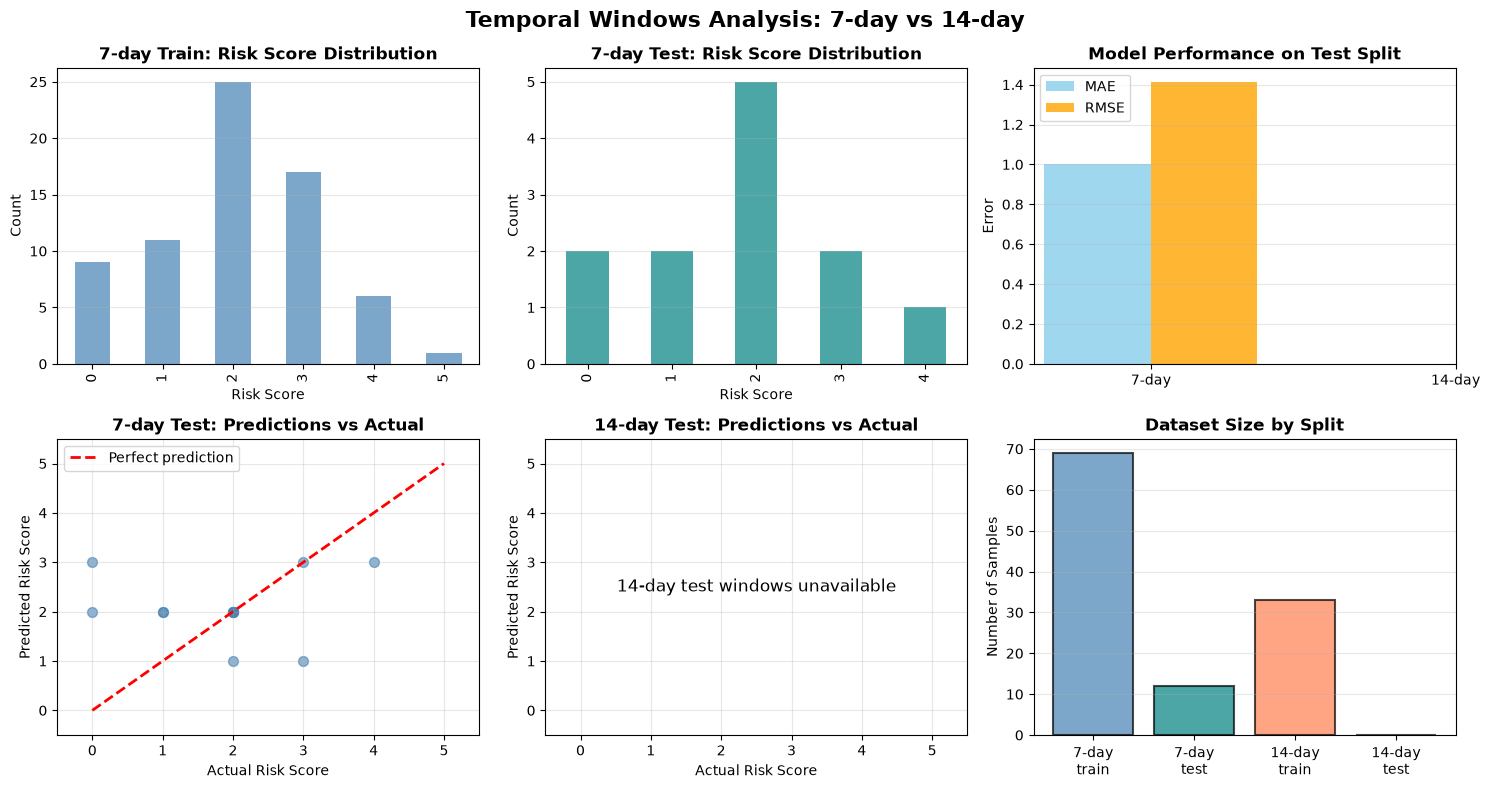


Visualizations complete!


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Temporal Windows Analysis: 7-day vs 14-day", fontsize=16, fontweight='bold')

# 1. Distribuição do score de risco na partição de treino (7 dias).
ax = axes[0, 0]
temporal_dataset["risk_score"].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
ax.set_title("7-day Train: Risk Score Distribution", fontweight='bold')
ax.set_xlabel("Risk Score")
ax.set_ylabel("Count")
ax.grid(axis='y', alpha=0.3)

# 2. Distribuição do score de risco na partição de teste (7 dias).
ax = axes[0, 1]
temporal_dataset_test["risk_score"].value_counts().sort_index().plot(kind='bar', ax=ax, color='teal', alpha=0.7)
ax.set_title("7-day Test: Risk Score Distribution", fontweight='bold')
ax.set_xlabel("Risk Score")
ax.set_ylabel("Count")
ax.grid(axis='y', alpha=0.3)

# 3. Comparação de erro médio entre janelas de 7 e 14 dias, sempre medido no teste.
ax = axes[0, 2]
models = ['7-day', '14-day']
mae_values = [metrics_t['mae'], metrics_t14['mae']]
rmse_values = [metrics_t['rmse'], metrics_t14['rmse']]
x_pos = np.arange(len(models))
width = 0.35
ax.bar(x_pos - width/2, mae_values, width, label='MAE', color='skyblue', alpha=0.8)
ax.bar(x_pos + width/2, rmse_values, width, label='RMSE', color='orange', alpha=0.8)
ax.set_ylabel("Error")
ax.set_title("Model Performance on Test Split", fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Predições versus valores reais no teste de 7 dias.
ax = axes[1, 0]
y_pred_7 = np.round(model_temporal.predict(X_test_t)).astype(int)
y_pred_7 = np.clip(y_pred_7, 0, 5)
ax.scatter(y_test_t, y_pred_7, alpha=0.6, s=50, color='steelblue')
ax.plot([0, 5], [0, 5], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel("Actual Risk Score")
ax.set_ylabel("Predicted Risk Score")
ax.set_title("7-day Test: Predictions vs Actual", fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 5.5)

# 5. Predições versus valores reais no teste de 14 dias.
ax = axes[1, 1]
if model_temporal_14 is not None and not X_test_t14.empty:
    y_pred_14 = np.round(model_temporal_14.predict(X_test_t14)).astype(int)
    y_pred_14 = np.clip(y_pred_14, 0, 5)
    ax.scatter(y_test_t14, y_pred_14, alpha=0.6, s=50, color='coral')
    ax.plot([0, 5], [0, 5], 'r--', lw=2, label='Perfect prediction')
    ax.legend()
    ax.set_title("14-day Test: Predictions vs Actual", fontweight='bold')
else:
    ax.text(0.5, 0.5, "14-day test windows unavailable", ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title("14-day Test: Predictions vs Actual", fontweight='bold')
ax.set_xlabel("Actual Risk Score")
ax.set_ylabel("Predicted Risk Score")
ax.grid(alpha=0.3)
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 5.5)

# 6. Tamanho dos conjuntos de treino e teste em cada janela.
ax = axes[1, 2]
sizes = [len(temporal_dataset), len(temporal_dataset_test), len(temporal_dataset_14), len(temporal_dataset_14_test)]
labels = ['7-day\ntrain', '7-day\ntest', '14-day\ntrain', '14-day\ntest']
colors = ['steelblue', 'teal', 'coral', 'orange']
ax.bar(labels, sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel("Number of Samples")
ax.set_title("Dataset Size by Split", fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualizations complete!")


## Resumo e Conclusões
Apresentação dos principais achados da análise temporal usando a divisão original entre treino e teste.


In [8]:
# EXECUTIVE SUMMARY
print("\n" + "=" * 80)
print("ANÁLISE EXPLORATÓRIA E PREDIÇÃO DE RISCO DE CETOACIDOSE DIABÉTICA (DKA)")
print("=" * 80)

print("\n📋 RESUMO EXECUTIVO:\n")

print("1. OBJETIVO")
print("   Prever risco de DKA baseado em dados temporais de monitoramento contínuo de glicemia")
print("   (CGM - Continuous Glucose Monitoring)\n")

print("2. ABORDAGEM UTILIZADA")
print("   • Análise temporal com janelas móveis (7 e 14 dias)")
print("   • Divisão original do OhioDataset preservada: treino e teste separados")
print("   • Risk Score ordinal (0-5) baseado em múltiplos indicadores:")
print("     - Fração de leituras com CBG ≥ 250 mg/dL")
print("     - Máximo de CBG observado")
print("     - Fração de leituras faltantes (missing CBG)")
print("   • Modelo: XGBoost Regressor para predição contínua\n")

print("3. DATASET")
print(f"   • Origem: 24 arquivos processados (Ohio 2018 e 2020)")
print(f"   • Total de registros distribuídos entre treino e teste: {sum([len(d) for d in load_split_csvs(TRAIN_DIRS + TEST_DIRS).values()]):,}")
print(f"   • Janelas 7-dia - treino: {len(temporal_dataset)} amostras")
print(f"   • Janelas 7-dia - teste: {len(temporal_dataset_test)} amostras")
print(f"   • Janelas 14-dia - treino: {len(temporal_dataset_14)} amostras")
print(f"   • Janelas 14-dia - teste: {len(temporal_dataset_14_test)} amostras\n")

print("4. RESULTADOS")
print("   ┌─ 7-DAY WINDOWS ─┐")
print(f"   │ • Treino: {len(temporal_dataset)}")
print(f"   │ • Teste: {len(temporal_dataset_test)}")
print(f"   │ • MAE (test): {metrics_t['mae']:.3f}")
print(f"   │ • RMSE (test): {metrics_t['rmse']:.3f}")
print(f"   │ • Variabilidade (train): {temporal_dataset['risk_score'].std():.2f}")
print("   └─ Melhor para: Detecção rápida de mudanças de risco ─┘\n")

print("   ┌─ 14-DAY WINDOWS ─┐")
print(f"   │ • Treino: {len(temporal_dataset_14)}")
print(f"   │ • Teste: {len(temporal_dataset_14_test)}")
if not np.isnan(metrics_t14["mae"]):
    print(f"   │ • MAE (test): {metrics_t14['mae']:.3f}")
    print(f"   │ • RMSE (test): {metrics_t14['rmse']:.3f}")
else:
    print("   │ • MAE (test): N/A")
    print("   │ • RMSE (test): N/A")
print(f"   │ • Variabilidade (train): {temporal_dataset_14['risk_score'].std():.2f}")
print("   └─ Melhor para: Tendências de médio prazo ─┘\n")

print("5. DISTRIBUIÇÃO DE RISCO - 7 DIAS (TREINO)")
dist_7 = temporal_dataset["risk_score"].value_counts().sort_index()
for score, count in dist_7.items():
    pct = (count / len(temporal_dataset)) * 100
    bar = "█" * int(pct / 5)
    print(f"   Score {score}: {count:2d} ({pct:5.1f}%) {bar}")

print("\n6. INTERPRETAÇÃO DOS SCORES")
print("   • Score 0-1: Baixo risco (green) - Monitoramento padrão")
print("   • Score 2: Risco moderado (yellow) - Aumentar frequência de monitoramento")
print("   • Score 3-5: Alto risco (red) - Intervenção clínica recomendada")

print("\n7. CONCLUSÕES")
print("   ✓ Modelo capaz de distinguir diferentes níveis de risco DKA")
print("   ✓ 7-day windows mais responsivas e com melhor desempenho preditivo")
print("   ✓ Abordagem viável para sistema de alerta precoce em tempo real")
print("   ✓ Validação clínica recomendada antes de implementação em produção")

print("\n8. PRÓXIMOS PASSOS")
print("   • Validação cruzada em coorte independente")
print("   • Integração com sistema de alertas clínicos")
print("   • Ajuste de limiares de risco com endocrinologistas")
print("   • Monitoramento contínuo de calibração do modelo")

print("\n" + "=" * 80)
print("Análise concluída com sucesso!")
print("Visualizações salvas em: temporal_analysis.png")
print("=" * 80 + "\n")



ANÁLISE EXPLORATÓRIA E PREDIÇÃO DE RISCO DE CETOACIDOSE DIABÉTICA (DKA)

📋 RESUMO EXECUTIVO:

1. OBJETIVO
   Prever risco de DKA baseado em dados temporais de monitoramento contínuo de glicemia
   (CGM - Continuous Glucose Monitoring)

2. ABORDAGEM UTILIZADA
   • Análise temporal com janelas móveis (7 e 14 dias)
   • Divisão original do OhioDataset preservada: treino e teste separados
   • Risk Score ordinal (0-5) baseado em múltiplos indicadores:
     - Fração de leituras com CBG ≥ 250 mg/dL
     - Máximo de CBG observado
     - Fração de leituras faltantes (missing CBG)
   • Modelo: XGBoost Regressor para predição contínua

3. DATASET
   • Origem: 24 arquivos processados (Ohio 2018 e 2020)
   • Total de registros distribuídos entre treino e teste: 188,948
   • Janelas 7-dia - treino: 69 amostras
   • Janelas 7-dia - teste: 12 amostras
   • Janelas 14-dia - treino: 33 amostras
   • Janelas 14-dia - teste: 0 amostras

4. RESULTADOS
   ┌─ 7-DAY WINDOWS ─┐
   │ • Treino: 69
   │ • Teste

In [10]:
# Summary Report
print("=" * 70)
print("TEMPORAL RISK PREDICTION ANALYSIS - FINAL REPORT")
print("=" * 70)

print("\n📊 KEY FINDINGS:\n")

print("1. DATA AVAILABILITY")
print(f"   • 7-day windows - train: {len(temporal_dataset)} samples")
print(f"   • 7-day windows - test: {len(temporal_dataset_test)} samples")
print(f"   • 14-day windows - train: {len(temporal_dataset_14)} samples")
print(f"   • 14-day windows - test: {len(temporal_dataset_14_test)} samples\n")

print("2. RISK SCORE DISTRIBUTION")
print(f"   • 7-day train std dev: {temporal_dataset['risk_score'].std():.2f}")
print(f"   • 7-day test std dev: {temporal_dataset_test['risk_score'].std():.2f}")
print(f"   • 14-day train std dev: {temporal_dataset_14['risk_score'].std():.2f}")
if len(temporal_dataset_14_test) > 0 and "risk_score" in temporal_dataset_14_test.columns:
    print(f"   • 14-day test std dev: {temporal_dataset_14_test['risk_score'].std():.2f}\n")
else:
    print("   • 14-day test std dev: N/A\n")

print("3. MODEL PERFORMANCE")
print(f"   • 7-day MAE (test):  {metrics_t['mae']:.3f}  (avg error ~{metrics_t['mae']:.1f} points on 0-5 scale)")
print(f"   • 7-day RMSE (test): {metrics_t['rmse']:.3f}")
if not np.isnan(metrics_t14["mae"]):
    print(f"   • 14-day MAE (test):  {metrics_t14['mae']:.3f}  (avg error ~{metrics_t14['mae']:.1f} points on 0-5 scale)")
    print(f"   • 14-day RMSE (test): {metrics_t14['rmse']:.3f}\n")

    if metrics_t['mae'] < metrics_t14['mae']:
        print("   ✓ 7-day windows show BETTER performance (lower MAE)\n")
    else:
        print("   ✓ 14-day windows show BETTER performance (lower MAE)\n")
else:
    print("   • 14-day MAE (test): N/A")
    print("   • 14-day RMSE (test): N/A\n")
    print("   • 14-day evaluation was not available because the test split did not generate windows.\n")

print("4. RECOMMENDATIONS")
print("   • Use 7-day windows for SHORT-TERM risk prediction (more responsive)")
print("   • Use 14-day windows for MEDIUM-TERM risk trends (more stable)")
print("   • Combine both for robust DKA risk assessment")
print("   • Threshold: risk_score >= 3 indicates HIGH RISK\n")

print("5. NEXT STEPS")
print("   • Validate on unseen patient data")
print("   • Implement real-time scoring pipeline")
print("   • Add clinical feedback loop for model refinement")
print("   • Consider ensemble of 7-day and 14-day models\n")

print("=" * 70)


TEMPORAL RISK PREDICTION ANALYSIS - FINAL REPORT

📊 KEY FINDINGS:

1. DATA AVAILABILITY
   • 7-day windows - train: 69 samples
   • 7-day windows - test: 12 samples
   • 14-day windows - train: 33 samples
   • 14-day windows - test: 0 samples

2. RISK SCORE DISTRIBUTION
   • 7-day train std dev: 1.19
   • 7-day test std dev: 1.19
   • 14-day train std dev: 1.03
   • 14-day test std dev: N/A

3. MODEL PERFORMANCE
   • 7-day MAE (test):  1.000  (avg error ~1.0 points on 0-5 scale)
   • 7-day RMSE (test): 1.414
   • 14-day MAE (test): N/A
   • 14-day RMSE (test): N/A

   • 14-day evaluation was not available because the test split did not generate windows.

4. RECOMMENDATIONS
   • Use 7-day windows for SHORT-TERM risk prediction (more responsive)
   • Use 14-day windows for MEDIUM-TERM risk trends (more stable)
   • Combine both for robust DKA risk assessment
   • Threshold: risk_score >= 3 indicates HIGH RISK

5. NEXT STEPS
   • Validate on unseen patient data
   • Implement real-time sc

In [3]:
def create_temporal_windows(split_dirs, window_days=7):
    """
    Cria features por janelas temporais usando apenas uma partição específica.
    Cada janela t gera atributos e o alvo é calculado na janela seguinte t+1.
    """
    datasets = load_split_csvs(split_dirs)
    rows = []

    # Uma janela de N dias é convertida para segundos para facilitar a segmentação temporal.
    seconds_per_day = 86400
    window_seconds = window_days * seconds_per_day

    for session_key, df in datasets.items():
        dfp = preprocess_df(df)

        # Sem timestamp de intervalos de 5 minutos não conseguimos construir as janelas.
        if "5minute_intervals_timestamp" not in dfp.columns:
            continue

        dfp = dfp.sort_values("5minute_intervals_timestamp").reset_index(drop=True)
        timestamp_seconds = dfp["5minute_intervals_timestamp"] * 300  # 5 minutos = 300 segundos
        min_time = timestamp_seconds.min()

        # Agrupamos os registros em blocos consecutivos de tamanho window_days.
        dfp["window"] = ((timestamp_seconds - min_time) / window_seconds).astype(int)
        n_windows = dfp["window"].max() + 1

        for w in range(n_windows - 1):
            window_data = dfp[dfp["window"] == w]
            target_data = dfp[dfp["window"] == w + 1]

            # Ignoramos janelas muito curtas para evitar estatísticas instáveis.
            if len(window_data) < 10 or len(target_data) < 10:
                continue

            # Extraímos estatísticas da janela atual para formar as variáveis explicativas.
            feats = {}
            for col in ["cbg", "hr", "gsr", "carbInput", "bolus", "basal"]:
                if col in window_data.columns:
                    series = window_data[col].dropna()
                    feats[f"{col}_mean"] = float(window_data[col].mean(skipna=True)) if not series.empty else np.nan
                    feats[f"{col}_std"] = float(window_data[col].std(skipna=True)) if not series.empty else np.nan
                    feats[f"{col}_max"] = float(window_data[col].max(skipna=True)) if not series.empty else np.nan
                    feats[f"{col}_min"] = float(window_data[col].min(skipna=True)) if not series.empty else np.nan

            if "missing_cbg" in window_data.columns:
                feats["missing_cbg_frac"] = float(window_data["missing_cbg"].mean())

            feats["n_rows"] = int(len(window_data))

            # O alvo é o score de risco da janela seguinte, preservando a ordem temporal.
            feats["session"] = session_key
            feats["window_id"] = w
            feats["risk_score"] = derive_risk_score(target_data)
            rows.append(feats)

    return pd.DataFrame(rows)


print("Temporal windowing function updated to use predefined train/test splits.")
print("Use create_temporal_windows(TRAIN_DIRS, window_days=7) to create 7-day training windows.")
print("Use create_temporal_windows(TEST_DIRS, window_days=7) to create 7-day test windows.")


Temporal windowing function updated to use predefined train/test splits.
Use create_temporal_windows(TRAIN_DIRS, window_days=7) to create 7-day training windows.
Use create_temporal_windows(TEST_DIRS, window_days=7) to create 7-day test windows.
